## 순서

#### 1. 라이브러리 불러오기
#### 2. 데이터 준비하기 (stanford_dogs)
#### 3. Augmentation 적용하기
#### 4. ResNet 50 모델 불러오기 (Imagenet으로 훈련된)
     4-1. ResNet-50 모델 불러오기
     4-2. no_aug로 학습하기
     4-3. aug로 학습하기
     4-4. 시각화
#### 5. 데이터셋을 cutmix 와 mixup에 적용하기
     5-1. cutmix에 적용하기
     5-2. cutmix로 ResNet-50 학습하기
     5-3. mixup에 적용하기
     5-4. mixup으로 ResNet-50 학습하기
     5-5. 시각화
#### 6. 회고

#### 1. 라이브러리 불러오기

In [49]:
# PyTorch and torchvision
import torch
import torchvision

# Helper libraries
import numpy as np
import matplotlib.pyplot as plt

print(torch.__version__)
print(np.__version__)

2.7.1+cu118
2.2.6


In [50]:
# GPU 확인
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


#### 2. 데이터 준비하기 (stanford_dogs)

In [51]:
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split
import torchvision.transforms as transforms

dataset_dir = "~/work/data_augmentation/data/Images/"

transform = transforms.Compose([
    transforms.Resize((224, 224)),  # 크기 통일
    transforms.ToTensor(),  # Tensor 변환
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])  # 정규화 추가
])
full_dataset = ImageFolder(root=dataset_dir, transform=transform)

total_size = len(full_dataset)
train_size = int(0.583 * total_size)  # 약 12,000개
test_size = total_size - train_size   # 약 8,580개
ds_train, ds_test = random_split(full_dataset, [train_size, test_size])

train_loader = DataLoader(ds_train, batch_size=32, shuffle=True)
test_loader = DataLoader(ds_test, batch_size=32, shuffle=False)
ds_info = {
    "num_classes": len(full_dataset.classes),
    "class_names": full_dataset.classes
}

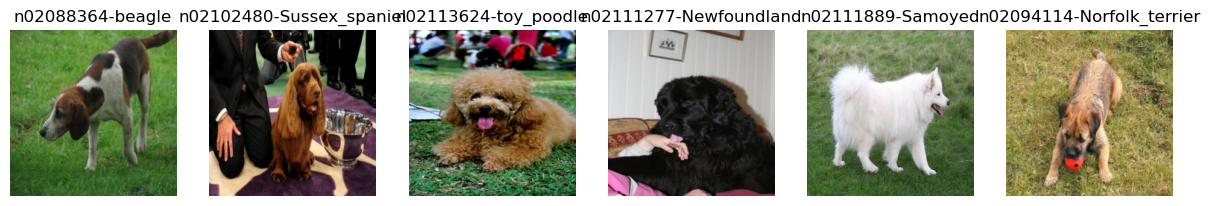

In [52]:
# DataLoader에서 일부 배치 가져오기
def show_examples(data_loader, class_names, num_images=6):
    data_iter = iter(data_loader)
    images, labels = next(data_iter)

    fig, axes = plt.subplots(1, num_images, figsize=(15, 5))
    for i in range(num_images):
        image = images[i].permute(1, 2, 0).numpy()  # (C, H, W) → (H, W, C)
        image = (image * 0.5) + 0.5
        image = np.clip(image, 0, 1)

        axes[i].imshow(image)
        axes[i].axis('off')
        axes[i].set_title(class_names[labels[i].item()])

    plt.show()

# 훈련 데이터 샘플 시각화
show_examples(train_loader, ds_info["class_names"])

#### 3. Augmentation 적용하기

#### 이미지 변환 전처리

In [53]:
def normalize_and_resize_img():
    return transforms.Compose([
        transforms.Resize((224, 224)),  # 크기 통일
        transforms.ToTensor(),  # Tensor 변환
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])  # 정규화 추가
    ])

transform = normalize_and_resize_img()
full_dataset = ImageFolder(root=dataset_dir, transform=transform)

In [54]:
def augment():
    return transforms.Compose([
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.ColorJitter(brightness=0.2)
    ])

#### 더 많은 Random 적용시

In [55]:
# 데이터셋을 가공하는 메인함수
def apply_normalize_on_dataset(dataset, is_test=False, batch_size=16, with_aug=False):
    transform = normalize_and_resize_img()

    if not is_test and with_aug:
        dataset.dataset.transform = transforms.Compose([
            *augment().transforms,
            *transform.transforms
        ])
    else:
        dataset.dataset.transform = transform

    return DataLoader(dataset, batch_size=batch_size, shuffle=not is_test, num_workers=2, pin_memory=True)

#### 4. ResNet 50 모델 불러오기 (Imagenet으로 훈련된)

##### 4-1. ResNet50 모델 불러오기


In [56]:
import torch.nn as nn
import torchvision.models as models

num_classes = len(ds_info["class_names"])
resnet50 = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
resnet50.fc = nn.Linear(resnet50.fc.in_features, num_classes)

aug_resnet50 = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
aug_resnet50.fc = nn.Linear(aug_resnet50.fc.in_features, num_classes)

ds_train_no_aug = apply_normalize_on_dataset(ds_train, with_aug=False)
ds_train_aug = apply_normalize_on_dataset(ds_train, with_aug=True)
ds_test = apply_normalize_on_dataset(ds_test, is_test=True)

##### 4-2. no_aug로 학습하기

In [57]:
%%time
import torch.optim as optim

EPOCH = 10
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(resnet50.parameters(), lr=0.001)

def train(model, train_loader, test_loader, epochs):
    model.to(device)
    history = {'val_accuracy': []}

    for epoch in range(epochs):
        model.train()
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        train_acc = 100. * correct / total
        print(f"Epoch [{epoch+1}/{epochs}], Accuracy: {train_acc:.2f}%")

        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()

        val_acc = 100. * correct / total
        history['val_accuracy'].append(val_acc)
        print(f"Validation Accuracy: {val_acc:.2f}%")

    return history

history_resnet50_no_aug = train(resnet50, ds_train_no_aug, ds_test, EPOCH)

Epoch [1/10], Accuracy: 13.47%
Validation Accuracy: 35.85%
Epoch [2/10], Accuracy: 45.28%
Validation Accuracy: 60.55%
Epoch [3/10], Accuracy: 60.41%
Validation Accuracy: 71.21%
Epoch [4/10], Accuracy: 69.25%
Validation Accuracy: 76.03%
Epoch [5/10], Accuracy: 74.48%
Validation Accuracy: 79.13%
Epoch [6/10], Accuracy: 77.10%
Validation Accuracy: 80.02%
Epoch [7/10], Accuracy: 79.68%
Validation Accuracy: 80.96%
Epoch [8/10], Accuracy: 81.36%
Validation Accuracy: 81.61%
Epoch [9/10], Accuracy: 83.71%
Validation Accuracy: 82.13%
Epoch [10/10], Accuracy: 84.65%
Validation Accuracy: 82.39%
CPU times: user 24min 25s, sys: 37.3 s, total: 25min 3s
Wall time: 24min 5s


##### 4-3. aug로 학습하기

In [58]:
%%time
import torch.optim as optim

EPOCH = 10
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(aug_resnet50.parameters(), lr=0.001)

def train(model, train_loader, test_loader, epochs):
    model.to(device)
    history = {'val_accuracy': []}

    for epoch in range(epochs):
        model.train()
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        train_acc = 100. * correct / total
        print(f"Epoch [{epoch+1}/{epochs}], Accuracy: {train_acc:.2f}%")

        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()

        val_acc = 100. * correct / total
        history['val_accuracy'].append(val_acc)
        print(f"Validation Accuracy: {val_acc:.2f}%")

    return history

history_resnet50_aug = train(aug_resnet50, ds_train_aug, ds_test, EPOCH)

Epoch [1/10], Accuracy: 15.46%
Validation Accuracy: 39.89%
Epoch [2/10], Accuracy: 45.54%
Validation Accuracy: 61.02%
Epoch [3/10], Accuracy: 61.25%
Validation Accuracy: 70.41%
Epoch [4/10], Accuracy: 69.32%
Validation Accuracy: 75.54%
Epoch [5/10], Accuracy: 74.66%
Validation Accuracy: 78.08%
Epoch [6/10], Accuracy: 77.20%
Validation Accuracy: 79.79%
Epoch [7/10], Accuracy: 79.68%
Validation Accuracy: 80.95%
Epoch [8/10], Accuracy: 81.41%
Validation Accuracy: 81.58%
Epoch [9/10], Accuracy: 83.71%
Validation Accuracy: 82.10%
Epoch [10/10], Accuracy: 84.84%
Validation Accuracy: 82.50%
CPU times: user 24min 30s, sys: 37.8 s, total: 25min 8s
Wall time: 24min 10s


##### 4-4. 시각화

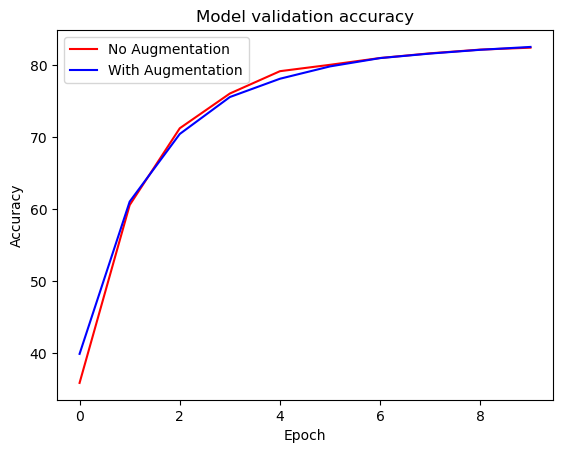

In [59]:
plt.plot(history_resnet50_no_aug['val_accuracy'], 'r', label='No Augmentation')
plt.plot(history_resnet50_aug['val_accuracy'], 'b', label='With Augmentation')
plt.title('Model validation accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.show()

##### 시각화 확대

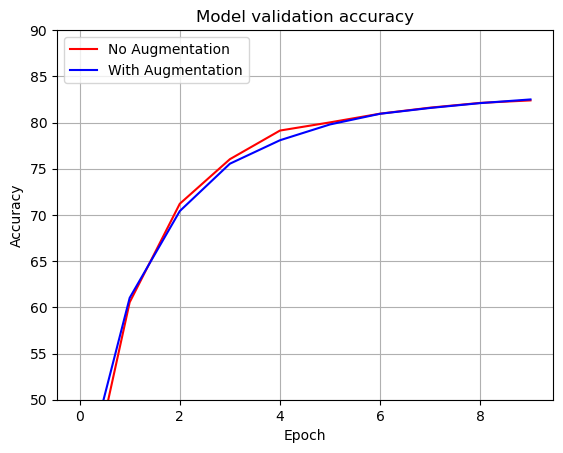

In [60]:
plt.plot(history_resnet50_no_aug['val_accuracy'], 'r', label='No Augmentation')
plt.plot(history_resnet50_aug['val_accuracy'], 'b', label='With Augmentation')
plt.title('Model validation accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.grid(True)
plt.ylim(50, 90)    # 출력하고자 하는  Accuracy 범위를 지정해 주세요.
#plt.ylim(0.72, 0.76)  # EPOCH=20으로 진행한다면 이 범위가 적당합니다.
plt.show()

### 5. 데이터셋을 cutmix 와 mixup에 적용하기

##### 5-1. cutmix에 적용하기

##### 1) 이미지 섞기

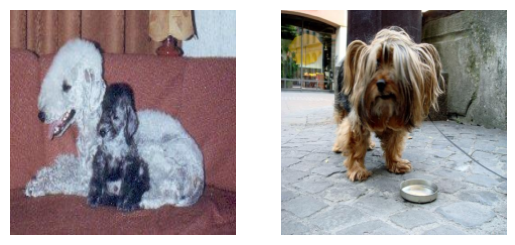

In [61]:
import matplotlib.pyplot as plt

# 데이터셋에서 이미지 2개를 가져옵니다.
data_iter = iter(train_loader)
images, labels = next(data_iter)

# 첫 번째 배치에서 두 개의 이미지 선택
image_a = images[0].permute(1, 2, 0).numpy()
image_b = images[1].permute(1, 2, 0).numpy()
label_a = labels[0].item()
label_b = labels[1].item()

# 정규화된 텐서를 다시 [0, 1] 범위로 조정
image_a = (image_a * 0.5) + 0.5
image_b = (image_b * 0.5) + 0.5

# 이미지 출력
plt.subplot(1, 2, 1)
plt.imshow(image_a)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(image_b)
plt.axis('off')

plt.show()

In [62]:
def get_clip_box(image_a, image_b):
    # image.shape = (channel, height, width)
    image_size_x = image_a.shape[2]  # Width
    image_size_y = image_a.shape[1]  # Height

    # Get center of box
    x = torch.randint(0, image_size_x, (1,)).item()
    y = torch.randint(0, image_size_y, (1,)).item()

    width = max(1, int(image_size_x * torch.sqrt(1 - torch.rand(1)).item()))
    height = max(1, int(image_size_y * torch.sqrt(1 - torch.rand(1)).item()))

    # Clip box in image and get minmax bbox
    x_min = max(0, x - width // 2)
    y_min = max(0, y - height // 2)
    x_max = min(image_size_x, x + width // 2 + 1)
    y_max = min(image_size_y, y + height // 2 + 1)

    return x_min, y_min, x_max, y_max

x_min, y_min, x_max, y_max = get_clip_box(image_a, image_b)

print('x :', x_min, x_max)
print('y :', y_min, y_max)

x : 0 3
y : 48 171


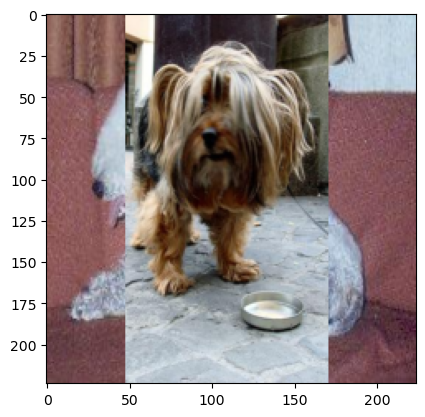

In [63]:
import torch

def mix_2_images(image_a, image_b, x_min, y_min, x_max, y_max):
    # image.shape = (C, H, W)
    image_size_x = image_a.shape[2]  # Width
    image_size_y = image_a.shape[1]  # Height

    if isinstance(image_a, np.ndarray):
        image_a = torch.from_numpy(image_a).to(device)
    if isinstance(image_b, np.ndarray):
        image_b = torch.from_numpy(image_b).to(device)

    top = image_a[:, :y_min, :]
    middle_left = image_a[:, y_min:y_max, :x_min]
    middle_center = image_b[:, y_min:y_max, x_min:x_max]
    middle_right = image_a[:, y_min:y_max, x_max:]
    bottom = image_a[:, y_max:, :]

    top = top.to(device)
    middle_left = middle_left.to(device)
    middle_center = middle_center.to(device)
    middle_right = middle_right.to(device)
    bottom = bottom.to(device)

    # 중간 부분(왼쪽, 중앙, 오른쪽) 결합
    middle = torch.cat([middle_left, middle_center, middle_right], dim=2)

    # 전체 이미지 결합 (위 + 중간 + 아래)
    mixed_img = torch.cat([top, middle, bottom], dim=1)

    return mixed_img

mixed_img = mix_2_images(image_a, image_b, x_min, y_min, x_max, y_max)

plt.imshow(mixed_img.cpu().numpy())
plt.show()

##### 2) 라벨 섞기

In [64]:
import torch.nn.functional as F

def mix_2_labels(label_a, label_b, x_min, y_min, x_max, y_max, num_classes=120):
    # 전역 변수 대신 고정된 이미지 크기(224) 사용 (안전함)
    image_size_x = 224  
    image_size_y = 224  

    # 바운딩 박스 비율 계산
    mixed_area = (x_max - x_min) * (y_max - y_min)
    total_area = image_size_x * image_size_y
    ratio = mixed_area / total_area

    
    label_a_onehot = F.one_hot(torch.tensor(int(label_a)), num_classes=num_classes).float().to(device)
    label_b_onehot = F.one_hot(torch.tensor(int(label_b)), num_classes=num_classes).float().to(device)

    # 비율에 따라 라벨 혼합
    mixed_label = (1 - ratio) * label_a_onehot + ratio * label_b_onehot
    return mixed_label

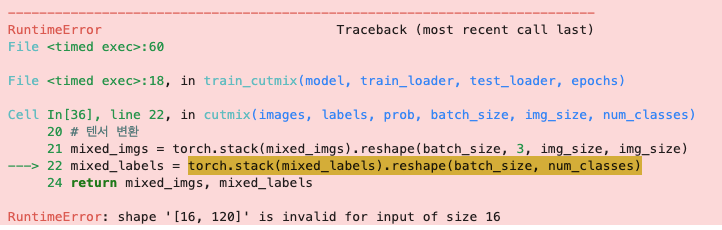
dataloader가 반환하는 라벨은 일반 정수(int)가 아닌 텐서(Tensor) 형태이므로, 이를 고려하지 않은 조건문에서 타입 오류 발생

해결방법 :
if isinstance(label_a, int): 부분을 지움

In [79]:
def cutmix(images, labels, prob=1.0, batch_size=16, img_size=224, num_classes=120):
    mixed_imgs = []
    mixed_labels = []

    for i in range(batch_size):
        image_a = images[i]
        label_a = labels[i]

        j = torch.randint(0, batch_size, (1,)).item()  # 다른 샘플 선택
        image_b = images[j]
        label_b = labels[j]

        # 바운딩 박스 생성
        x_min, y_min, x_max, y_max = get_clip_box(image_a, image_b)

        # 이미지 섞기
        mixed_imgs.append(mix_2_images(image_a, image_b, x_min, y_min, x_max, y_max))
        mixed_labels.append(mix_2_labels(label_a, label_b, x_min, y_min, x_max, y_max, num_classes))

    # 텐서 변환
    mixed_imgs = torch.stack(mixed_imgs).reshape(batch_size, 3, img_size, img_size)
    mixed_labels = torch.stack(mixed_labels).reshape(batch_size, num_classes)

    return mixed_imgs, mixed_labels

##### 5-2. cutmix로 ResNet-50 학습하기

In [ ]:
num_classes = len(ds_info["num_classes"])
cutmix_resnet50 = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
cutmix_resnet50.fc = nn.Linear(cutmix_resnet50.fc.in_features, num_classes)
cutmix_resnet50.to(device)

In [67]:
%%time
import torch.optim as optim

EPOCH = 10
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(cutmix_resnet50.parameters(), lr=0.001)

def train_cutmix(model, train_loader, test_loader, epochs):
    model.to(device)
    history = {'val_accuracy': []}

    for epoch in range(epochs):
        model.train()
        correct = 0
        total = 0

        for images, labels in train_loader:
            mixed_images, mixed_labels = cutmix(images, labels, batch_size=images.size(0), img_size=224, num_classes=num_classes)

            mixed_images = mixed_images.to(device)
            mixed_labels = mixed_labels.to(device)

            optimizer.zero_grad()
            outputs = model(mixed_images)
            
            loss = criterion(outputs, mixed_labels)
            loss.backward()
            optimizer.step()

            _, predicted = outputs.max(1)
            _, target_max = mixed_labels.max(1) 
            
            total += labels.size(0)
            correct += predicted.eq(target_max).sum().item()

        train_acc = 100. * correct / total
        print(f"Epoch [{epoch+1}/{epochs}], Train Accuracy: {train_acc:.2f}%")

        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()

        val_acc = 100. * correct / total
        history['val_accuracy'].append(val_acc)
        print(f"Validation Accuracy: {val_acc:.2f}%")

    return history

history_resnet50_cutmix = train_cutmix(cutmix_resnet50, ds_train_aug, ds_test, EPOCH)

Epoch [1/10], Train Accuracy: 3.78%
Validation Accuracy: 16.07%
Epoch [2/10], Train Accuracy: 16.24%
Validation Accuracy: 40.42%
Epoch [3/10], Train Accuracy: 27.45%
Validation Accuracy: 53.51%
Epoch [4/10], Train Accuracy: 35.61%
Validation Accuracy: 61.87%
Epoch [5/10], Train Accuracy: 40.15%
Validation Accuracy: 67.25%
Epoch [6/10], Train Accuracy: 44.01%
Validation Accuracy: 71.23%
Epoch [7/10], Train Accuracy: 47.33%
Validation Accuracy: 73.93%
Epoch [8/10], Train Accuracy: 49.63%
Validation Accuracy: 76.33%
Epoch [9/10], Train Accuracy: 51.97%
Validation Accuracy: 77.84%
Epoch [10/10], Train Accuracy: 53.00%
Validation Accuracy: 78.36%
CPU times: user 29min, sys: 39.6 s, total: 29min 39s
Wall time: 25min 15s


##### 5-3. mixup에 적용하기

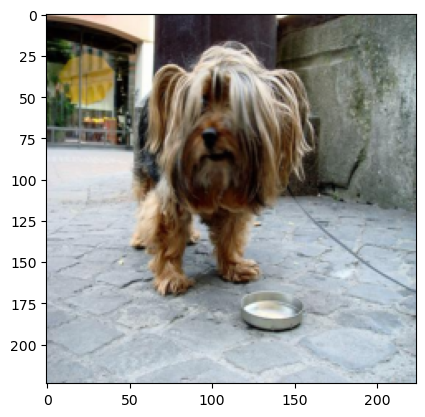

tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0025, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.9975, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
        0.0000, 0.0000, 0.0000, 0.0000, 

In [72]:
# function for mixup
def mixup_2_images(image_a, image_b, label_a, label_b, num_classes=120):
    ratio = torch.rand(1).item()  # 0~1 사이의 랜덤 값

    # 라벨 원핫 인코딩
    if isinstance(label_a, int):
        label_a = F.one_hot(torch.tensor(label_a), num_classes=num_classes).float()
    if isinstance(label_b, int):
        label_b = F.one_hot(torch.tensor(label_b), num_classes=num_classes).float()

    # 이미지와 라벨 혼합
    mixed_image = (1 - ratio) * image_a + ratio * image_b
    mixed_label = (1 - ratio) * label_a + ratio * label_b

    return mixed_image, mixed_label

# 예제 실행
mixed_img, mixed_label = mixup_2_images(image_a, image_b, label_a, label_b)

plt.imshow(mixed_img)
plt.show()

print(mixed_label)

In [73]:
def mixup(images, labels, batch_size=16, img_size=224, num_classes=120):
    mixed_imgs = []
    mixed_labels = []

    for i in range(batch_size):
        image_a = images[i]
        label_a = labels[i]

        # 랜덤하게 다른 이미지 선택
        j = torch.randint(0, batch_size, (1,)).item()
        image_b = images[j]
        label_b = labels[j]

        # Mixup 적용
        mixed_img, mixed_label = mixup_2_images(image_a, image_b, label_a, label_b, num_classes)

        mixed_imgs.append(mixed_img)
        mixed_labels.append(mixed_label)

    # 배치 차원 추가
    mixed_imgs = torch.stack(mixed_imgs).view(batch_size, 3, img_size, img_size)  # (B, C, H, W)
    mixed_labels = torch.stack(mixed_labels).view(batch_size, num_classes)  # (B, num_classes)

    return mixed_imgs, mixed_labels

##### 5-4. mixup으로 ResNet-50 학습하기

In [75]:
num_classes = ds_info["num_classes"]
mixup_resnet50 = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
mixup_resnet50.fc = nn.Linear(mixup_resnet50.fc.in_features, num_classes)

In [76]:
%%time
import torch.optim as optim

EPOCH = 10
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(mixup_resnet50.parameters(), lr=0.001)

def train_mixup(model, train_loader, test_loader, epochs):
    model.to(device)
    history = {'val_accuracy': []}

    for epoch in range(epochs):
        model.train()
        correct = 0
        total = 0

        for images, labels in train_loader:
            mixed_images, mixed_labels = cutmix(images, labels, batch_size=images.size(0), img_size=224, num_classes=num_classes)

            mixed_images = mixed_images.to(device)
            mixed_labels = mixed_labels.to(device)

            optimizer.zero_grad()
            outputs = model(mixed_images)
            
            loss = criterion(outputs, mixed_labels)
            loss.backward()
            optimizer.step()

            _, predicted = outputs.max(1)
            _, target_max = mixed_labels.max(1) 
            
            total += labels.size(0)
            correct += predicted.eq(target_max).sum().item()

        train_acc = 100. * correct / total
        print(f"Epoch [{epoch+1}/{epochs}], Train Accuracy: {train_acc:.2f}%")

        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()

        val_acc = 100. * correct / total
        history['val_accuracy'].append(val_acc)
        print(f"Validation Accuracy: {val_acc:.2f}%")

    return history

history_resnet50_mixup = train_mixup(mixup_resnet50, ds_train_aug, ds_test, EPOCH)

Epoch [1/10], Train Accuracy: 3.84%
Validation Accuracy: 16.39%
Epoch [2/10], Train Accuracy: 15.79%
Validation Accuracy: 41.75%
Epoch [3/10], Train Accuracy: 27.42%
Validation Accuracy: 53.30%
Epoch [4/10], Train Accuracy: 34.45%
Validation Accuracy: 62.53%
Epoch [5/10], Train Accuracy: 39.98%
Validation Accuracy: 66.95%
Epoch [6/10], Train Accuracy: 44.52%
Validation Accuracy: 71.09%
Epoch [7/10], Train Accuracy: 47.10%
Validation Accuracy: 73.40%
Epoch [8/10], Train Accuracy: 49.66%
Validation Accuracy: 75.83%
Epoch [9/10], Train Accuracy: 51.74%
Validation Accuracy: 76.82%
Epoch [10/10], Train Accuracy: 53.38%
Validation Accuracy: 78.49%
CPU times: user 29min 4s, sys: 39.8 s, total: 29min 44s
Wall time: 25min 17s


##### 5-5. 시각화

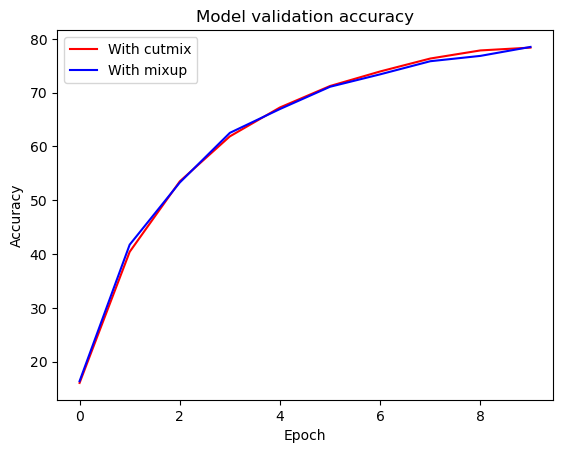

In [77]:
plt.plot(history_resnet50_cutmix['val_accuracy'], 'r', label='With cutmix')
plt.plot(history_resnet50_mixup['val_accuracy'], 'b', label='With mixup')
plt.title('Model validation accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.show()

#### no-aug / with aug / with cutmix /with mixup 시각화

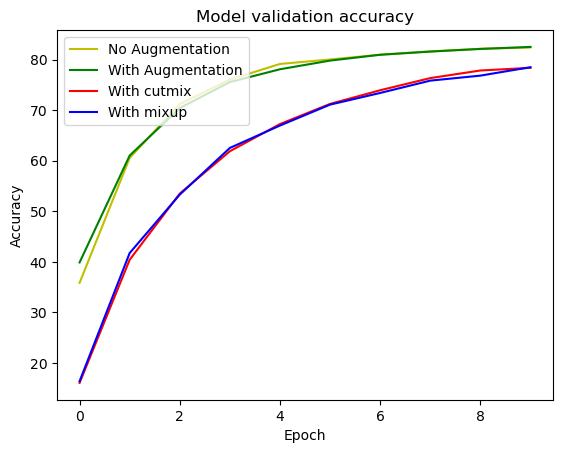

In [78]:
plt.plot(history_resnet50_no_aug['val_accuracy'], 'y', label='No Augmentation')
plt.plot(history_resnet50_aug['val_accuracy'], 'g', label='With Augmentation')
plt.plot(history_resnet50_cutmix['val_accuracy'], 'r', label='With cutmix')
plt.plot(history_resnet50_mixup['val_accuracy'], 'b', label='With mixup')
plt.title('Model validation accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.show()

### 6. 회고

분석결과
1. 20 epoch 까지 학습하기에는 시간이 많이 부족했다. 일단 최대 10 epoch로 진행.

2. No_aug : Accuracy: 84.65%, Validation Accuracy: 82.39%

   
   with_aug : Accuracy: 84.84%, Validation Accuracy: 82.50%

   
   with_cutmix : Train Accuracy: 53.00%, Validation Accuracy: 78.36%

   
   with_mixup : Train Accuracy: 53.38%, Validation Accuracy: 78.49%

4. 결과

   
   오히려 no_aug 와 with_aug의 성능이 더 좋은 것은 예상 밖의 결과였다. 이미지를 여러 형태로 바꾼 것이 초반에 모델이 학습하기가 어려웠던 것이 아닐까 라는 생각이 들었다

   그렇다면, Epoch 8 기준으로 accuracy의 기울기를 본다면 with cutmix와 with mixup은 조금더  Accuarcy가 올라갈 잠재력(?)이 충분히 있어보임

   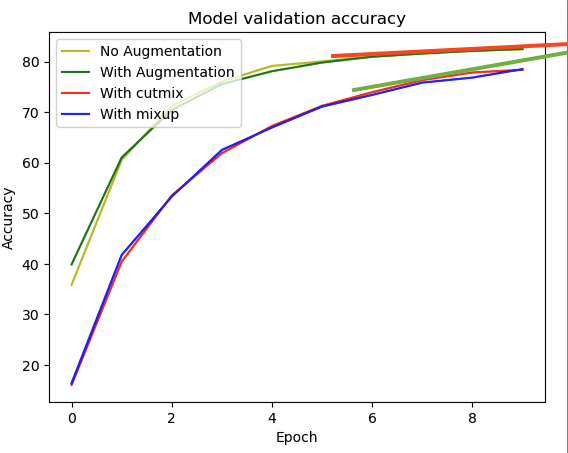

   마지막으로 추축인건데, 개냐 고양이냐 했으면 with cutmix와 with mixup이 좀 더 성능이 좋았을 것 같다. 이번 분석에서는 개 종류를 파악하기에는 원본 이미지를 그대로 둔 상태가 모델이 학습하기에 더 편했을지도 모른다.